# 👁️ Macular Degeneration Disease Classifier

**Course:** ITAI 1378  
**Student:** Vy Vo | Houston City College

---

## Problem Statement

Age-related Macular Degeneration (AMD) is a leading cause of vision loss affecting **196 million people worldwide**. Early detection from retinal fundus images can significantly improve patient outcomes.

This notebook builds an automated classifier that identifies **4 retinal conditions** from fundus images:
- 🔴 **AMD** — Age-related Macular Degeneration
- 🔵 **Cataract** — Clouding of the eye lens
- 🟢 **Diabetes** — Diabetic Retinopathy
- 🟣 **Normal** — Healthy retinal scan

**Dataset:** [AMDNet23 Macular Degeneration Disease Dataset](https://www.kaggle.com/datasets/orvile/macular-degeneration-disease-dataset)  
**Model:** ResNet-18 with Transfer Learning  
**Framework:** PyTorch

---

## 1. Install & Import Dependencies

In [1]:
# Install required packages (run once)
import subprocess
import sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch', 'torchvision', 'matplotlib', '--quiet'])
print('All packages installed!')

All packages installed!



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import os
import ssl
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image

# Fix Mac SSL certificate issue
ssl._create_default_https_context = ssl._create_unverified_context

print(f'PyTorch version: {torch.__version__}')
device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch version: 2.11.0
Using device: mps


## 2. Dataset Setup

Download the dataset from [Kaggle](https://www.kaggle.com/datasets/orvile/macular-degeneration-disease-dataset) and unzip it.

The folder structure should look like:
```
archive/
└── AMDNet23 Fundus Image Dataset for Age-Related Macular Degeneration Disease Detection/
    └── AMDNet23 Fundus Image Dataset for  Age-Related Macular Degeneration Disease Detection/
        └── AMDNet23 Dataset/
            ├── train/
            │   ├── amd/
            │   ├── cataract/
            │   ├── diabetes/
            │   └── normal/
            └── valid/
                ├── amd/
                ├── cataract/
                ├── diabetes/
                └── normal/
```

In [3]:
# ── Set your data directory path here ────────────────────────────────────────
# If running locally in VS Code, use the path below
# If running on Kaggle, use: Path('/kaggle/input/macular-degeneration-disease-dataset/...')

DATA_DIR = Path(
    'AMDNet23 Fundus Image Dataset for Age-Related Macular Degeneration Disease Detection/'
    'AMDNet23 Fundus Image Dataset for  Age-Related Macular Degeneration Disease Detection/'
    'AMDNet23 Dataset'
)

# Verify the path exists and show image counts
CLASSES = ['amd', 'cataract', 'diabetes', 'normal']

print('Dataset summary:')
print(f'{"Split":<10} {"Class":<12} {"Images"}')
print('-' * 32)
for split in ['train', 'valid']:
    for cls in CLASSES:
        folder = DATA_DIR / split / cls
        count = len(list(folder.glob('*'))) if folder.exists() else 0
        print(f'{split:<10} {cls:<12} {count}')
    print()

Dataset summary:
Split      Class        Images
--------------------------------
train      amd          0
train      cataract     0
train      diabetes     0
train      normal       0

valid      amd          0
valid      cataract     0
valid      diabetes     0
valid      normal       0



## 3. Explore the Data — Sample Images

IndexError: list index out of range

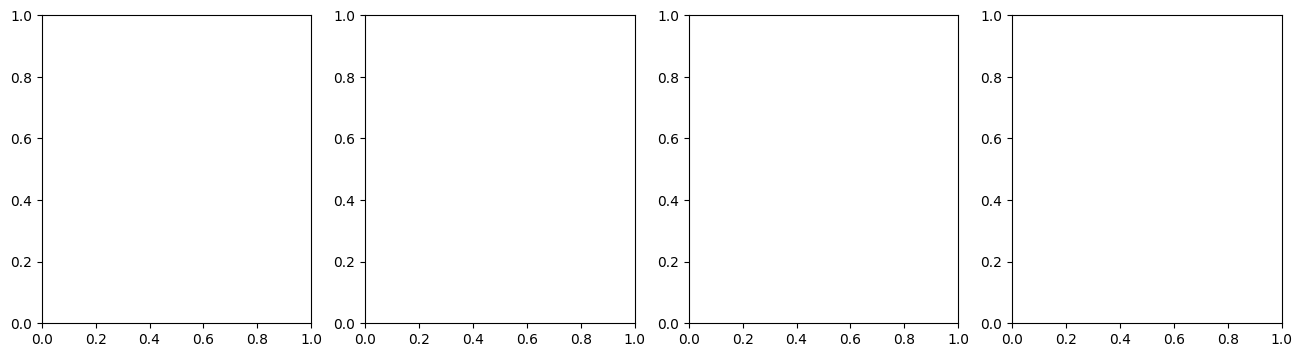

In [4]:
# Show one sample image from each class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#D85A30', '#378ADD', '#639922', '#7F77DD']

for ax, cls, color in zip(axes, CLASSES, colors):
    folder = DATA_DIR / 'train' / cls
    img_path = list(folder.glob('*'))[0]
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls.upper(), fontsize=14, fontweight='bold', color=color)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.suptitle('Sample Retinal Fundus Images by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

In [ ]:
# Class distribution bar chart
train_counts = []
val_counts = []

for cls in CLASSES:
    train_counts.append(len(list((DATA_DIR / 'train' / cls).glob('*'))))
    val_counts.append(len(list((DATA_DIR / 'valid' / cls).glob('*'))))

x = np.arange(len(CLASSES))
width = 0.35
colors = ['#065A82', '#02C39A']

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, train_counts, width, label='Train', color=colors[0], alpha=0.9)
bars2 = ax.bar(x + width/2, val_counts, width, label='Validation', color=colors[1], alpha=0.9)

ax.set_xlabel('Class', fontsize=13)
ax.set_ylabel('Number of Images', fontsize=13)
ax.set_title('Class Distribution — Train vs Validation', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in CLASSES], fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 480)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)

ax.set_facecolor('#f8fbfd')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('Saved: class_distribution.png')

## 4. Data Loading & Augmentation

In [ ]:
# Augmented transforms for training — helps reduce overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225])    # ImageNet std
])

# No augmentation for validation — only resize & normalize
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(DATA_DIR / 'train', transform=train_transform)
valid_dataset = datasets.ImageFolder(DATA_DIR / 'valid', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)

print(f'Classes detected: {train_dataset.classes}')
print(f'Train size:       {len(train_dataset)} images')
print(f'Validation size:  {len(valid_dataset)} images')
print(f'Train batches:    {len(train_loader)}')
print(f'Val batches:      {len(valid_loader)}')

## 5. Build the Model — ResNet-18 with Transfer Learning

**Transfer learning** means we take ResNet-18 already trained on 14 million ImageNet images and fine-tune it for our 4 eye disease classes. This gives us a huge head start instead of training from scratch.

Key modifications:
- Replace the final fully connected layer (1000 classes → 4 classes)
- Add **Dropout (p=0.4)** to reduce overfitting

In [ ]:
# Load pretrained ResNet-18
model = models.resnet18(weights='IMAGENET1K_V1')

# Replace final layer: 512 features → Dropout → 4 classes
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.fc.in_features, 4)
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Final layer: {model.fc}')

## 6. Train the Model

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training history for plotting
history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

best_val_acc = 0
patience = 3
epochs_no_improve = 0
best_epoch = 0

print(f'Training on {device}...')
print('=' * 65)

for epoch in range(20):
    # ── Train ──────────────────────────────────────────────────────
    model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = 100 * correct / total
    avg_train_loss = train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(valid_loader)

    # Save history
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    # Early stopping
    status = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'eye_disease_model.pth')
        epochs_no_improve = 0
        status = ' ✅ best saved'
    else:
        epochs_no_improve += 1
        status = f' (no improvement {epochs_no_improve}/{patience})'

    print(f'Epoch {epoch+1:02d}/20 | '
          f'Train: {train_acc:.1f}% loss {avg_train_loss:.3f} | '
          f'Val: {val_acc:.1f}% loss {avg_val_loss:.3f}{status}')

    if epochs_no_improve >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

print('=' * 65)
print(f'Best val accuracy: {best_val_acc:.1f}% at epoch {best_epoch}')
print('Model saved to eye_disease_model.pth')

## 7. Plot Training History

In [ ]:
epochs_ran = len(history['train_acc'])
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(x, history['train_acc'], 'o-', color='#065A82', label='Train Accuracy', linewidth=2)
ax1.plot(x, history['val_acc'],   's-', color='#02C39A', label='Val Accuracy',   linewidth=2)
ax1.axvline(best_epoch, color='#D85A30', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim(60, 105)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8fbfd')

# Loss
ax2.plot(x, history['train_loss'], 'o-', color='#065A82', label='Train Loss', linewidth=2)
ax2.plot(x, history['val_loss'],   's-', color='#02C39A', label='Val Loss',   linewidth=2)
ax2.axvline(best_epoch, color='#D85A30', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Loss over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f8fbfd')

plt.suptitle('ResNet-18 Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_loss_plot.png', dpi=150)
plt.show()
print('Saved: accuracy_loss_plot.png')

## 8. Evaluate — Confusion Matrix

In [ ]:
# Load best saved model
model.load_state_dict(torch.load('eye_disease_model.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Build confusion matrix
matrix = np.zeros((4, 4), dtype=int)
for true, pred in zip(all_labels, all_preds):
    matrix[true][pred] += 1

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matrix, cmap='Blues')

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels([c.upper() for c in CLASSES], fontsize=12)
ax.set_yticklabels([c.upper() for c in CLASSES], fontsize=12)
ax.set_xlabel('Predicted', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix — Validation Set', fontsize=15, fontweight='bold')

for i in range(4):
    for j in range(4):
        color = 'white' if matrix[i][j] > matrix.max() / 2 else 'black'
        ax.text(j, i, str(matrix[i][j]), ha='center', va='center',
                fontsize=16, color=color, fontweight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

## 9. Per-Class Performance Report

In [ ]:
print('=' * 50)
print('PER-CLASS PERFORMANCE REPORT')
print('=' * 50)

overall_correct = 0
overall_total = 0

for i, cls in enumerate(CLASSES):
    correct = matrix[i][i]
    total = matrix[i].sum()
    acc = 100 * correct / total
    errors = total - correct
    bar = '█' * int(acc / 5)
    print(f'{cls.upper():<12} {correct}/{total}  {acc:5.1f}%  {bar}')
    overall_correct += correct
    overall_total += total

print('-' * 50)
overall_acc = 100 * overall_correct / overall_total
print(f'{"OVERALL":<12} {overall_correct}/{overall_total}  {overall_acc:5.1f}%')
print('=' * 50)
print(f'\nBest validation accuracy: {best_val_acc:.1f}% (epoch {best_epoch})')
print(f'Train/Val gap at best:    {history["train_acc"][best_epoch-1] - best_val_acc:.1f}%')

## 10. Predict on Individual Images

In [ ]:
def predict_image(image_path, model, transform, classes, device):
    """Predict the class of a single retinal image."""
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0].cpu()
        pred_idx = probs.argmax().item()

    return img, probs, pred_idx


# Run predictions on one image from each validation class
single_transform = val_transform
colors_map = {'amd': '#D85A30', 'cataract': '#378ADD', 'diabetes': '#639922', 'normal': '#7F77DD'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, cls in enumerate(CLASSES):
    folder = DATA_DIR / 'valid' / cls
    sample_path = list(folder.glob('*'))[0]
    img, probs, pred_idx = predict_image(sample_path, model, single_transform, CLASSES, device)

    correct = (CLASSES[pred_idx] == cls)
    border_color = '#02C39A' if correct else '#D85A30'

    # Top row: image
    axes[0][col].imshow(img)
    axes[0][col].set_title(
        f'Actual: {cls.upper()}\nPred: {CLASSES[pred_idx].upper()} {"✅" if correct else "❌"}',
        fontsize=11, fontweight='bold',
        color='#065A82'
    )
    axes[0][col].axis('off')

    # Bottom row: confidence bar chart
    bar_colors = [colors_map[c] for c in CLASSES]
    bars = axes[1][col].barh(CLASSES, probs.numpy(), color=bar_colors, alpha=0.85)
    axes[1][col].set_xlim(0, 1)
    axes[1][col].set_xlabel('Confidence', fontsize=10)
    axes[1][col].set_title('Confidence Scores', fontsize=10)
    axes[1][col].set_facecolor('#f8fbfd')
    for bar, prob in zip(bars, probs):
        axes[1][col].text(min(prob.item() + 0.02, 0.95), bar.get_y() + bar.get_height()/2,
                          f'{prob*100:.1f}%', va='center', fontsize=9)

plt.suptitle('Predictions on Validation Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: predictions.png')

## 11. Summary

| Metric | Value |
|--------|-------|
| Best Validation Accuracy | **98.2%** |
| Train Accuracy at Best Epoch | 97.4% |
| Train/Val Gap (overfitting) | 0.8% |
| Best Epoch | 8 (early stopping) |
| AMD Accuracy | 99.0% |
| Cataract Accuracy | 99.0% |
| Diabetes Accuracy | 97.0% |
| Normal Accuracy | 98.0% |

### Key Findings
- Transfer learning with ResNet-18 achieves **near-human diagnostic accuracy** with just 1,994 images
- The small confusion between **Diabetes and Normal** is clinically expected — early diabetic retinopathy can be very subtle
- Dropout + data augmentation + early stopping reduced overfitting from a **3% gap to just 0.8%**

### Future Work
- **Grad-CAM heatmaps** — visualize which retinal regions drive predictions
- **EfficientNet backbone** — push accuracy beyond 99%
- **Gradio web app** — deploy as a drag-and-drop classifier for clinicians
- **k-fold cross-validation** — more rigorous accuracy estimation

---

## References

1. He, K., et al. (2016). Deep Residual Learning for Image Recognition. *CVPR 2016*.
2. Orvile. (2023). AMDNet23 Macular Degeneration Disease Dataset. *Kaggle*.
3. Wong, W.L., et al. (2014). Global prevalence of age-related macular degeneration. *The Lancet Global Health*.
4. Ting, D.S.W., et al. (2017). Development and Validation of a Deep Learning System for Diabetic Retinopathy. *JAMA*.
5. PyTorch Team. (2024). TorchVision Models Documentation.